# 🧩 K-Means - Iris dataset


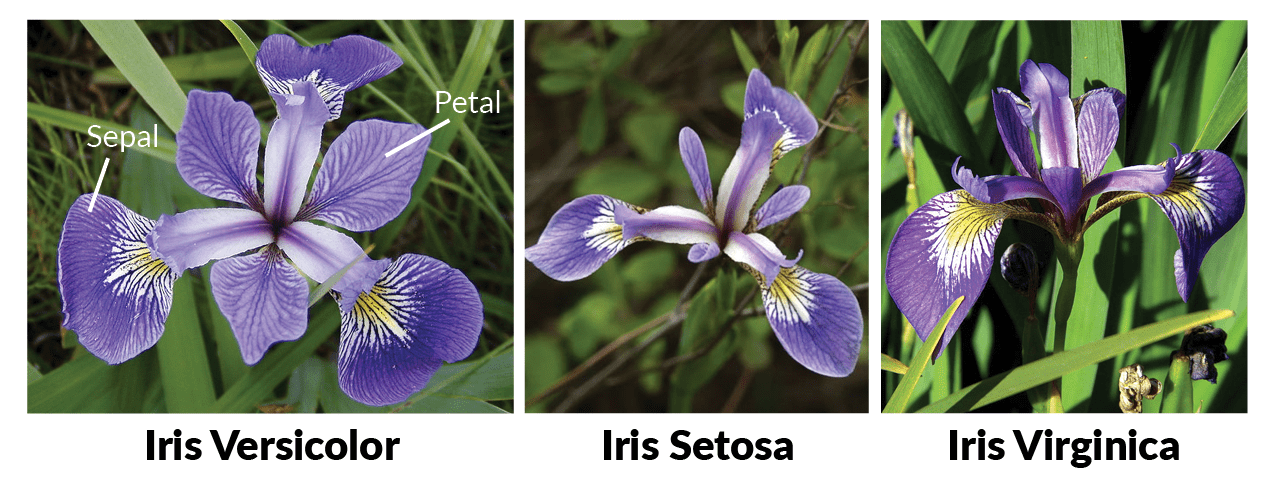



---

## 🎯 Objectius
- Aquest notebook mostra un exemple d'ús del model K-means per el dataset clàssic Iris

## 📦 Dataset Iris
- Utilitzarem el dataset classic de Iris

## 🟦 1. Import Classes

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

sns.set(style="whitegrid", context="notebook")



## 🟦 1. Load Data

In [24]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()

# Rename column names (més llegible)
df.columns = [
    "sepal_length", "sepal_width",
    "petal_length", "petal_width",
    "species_id"
]

feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_cols].to_numpy()
y_true = df["species_id"].to_numpy()

species_names = iris.target_names
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_id
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 🟦 2. Visualització inicial (sense clustering)


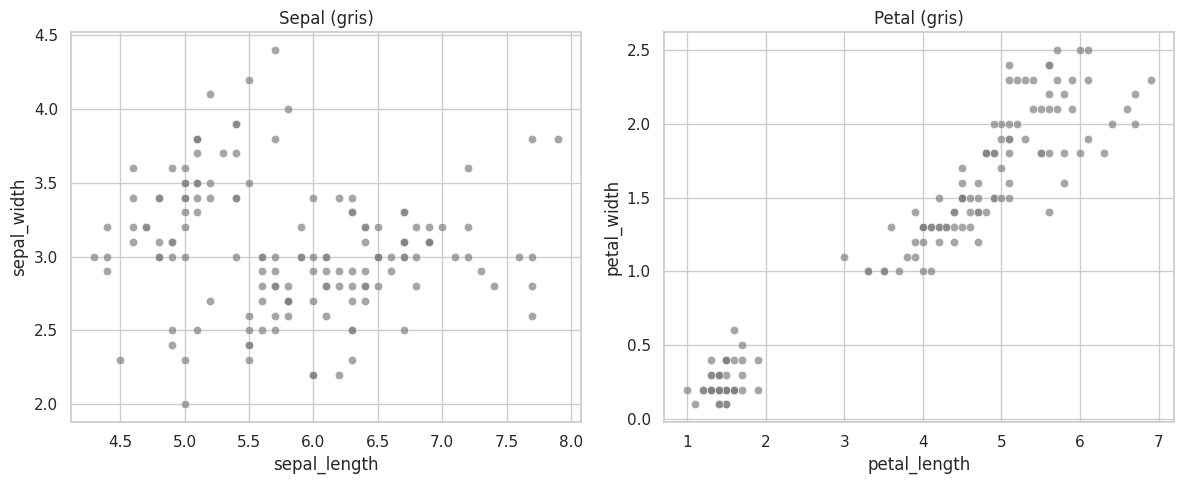

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width",
    color="grey", alpha=0.7, ax=axes[0]
)
axes[0].set_title("Sepal (gris)")

sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    color="grey", alpha=0.7, ax=axes[1]
)
axes[1].set_title("Petal (gris)")

plt.tight_layout()
plt.show()

## 🟦 3. Entrenament

In [26]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    algorithm="lloyd",
    random_state=42
)

kmeans.fit(X)
print(f"Inèrcia: {kmeans.inertia_}")


Inèrcia: 78.851441426146


In [27]:
df["cluster"] = kmeans.predict(X)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_id,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


## 🟦 4. Visualització

Mostrem 2 conjunts scatter plots a on es mostren les classes trobades per Kmeans i un a on es mostren

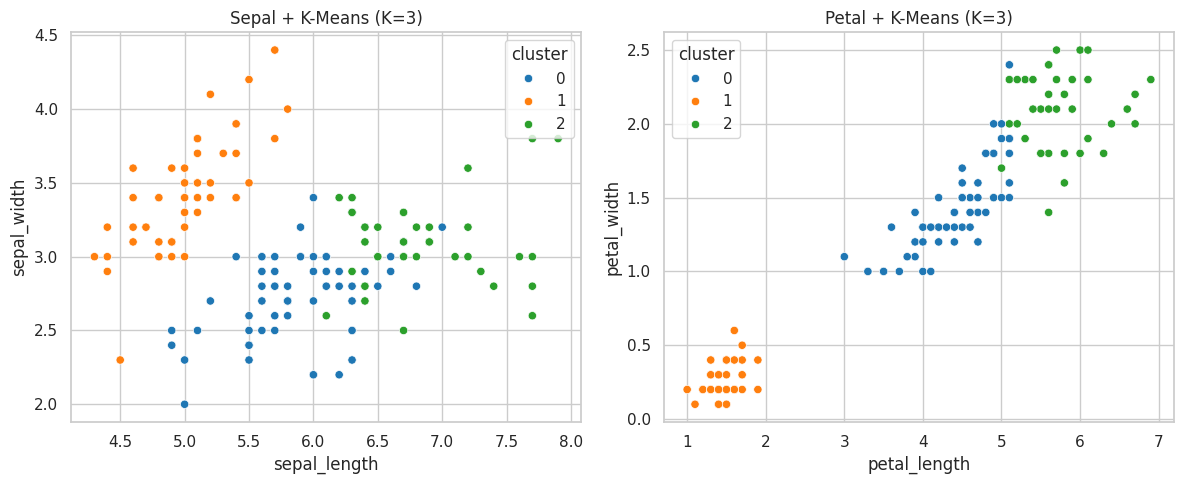

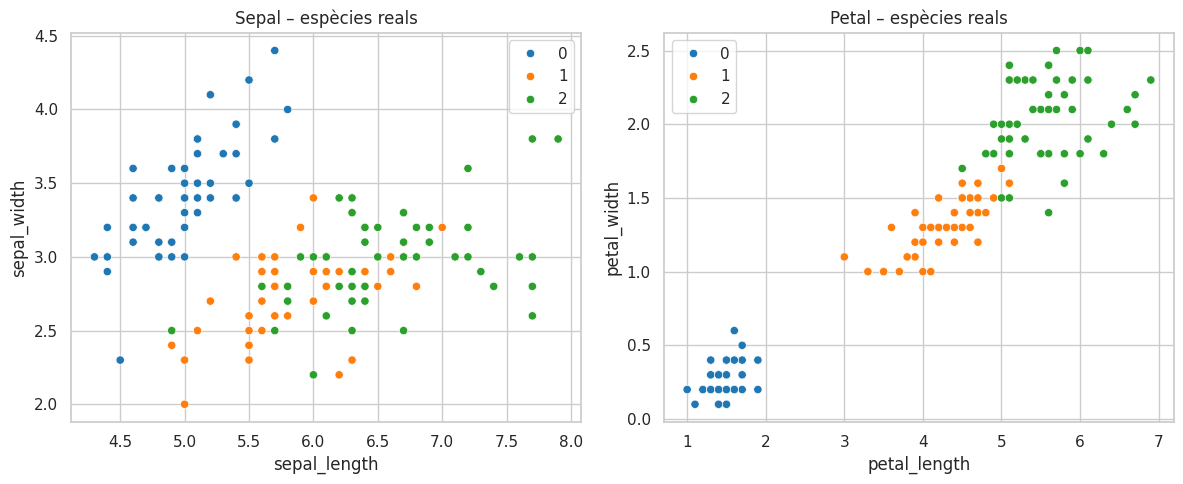

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width",
    hue="cluster", palette="tab10", ax=axes[0]
)
axes[0].set_title("Sepal + K-Means (K=3)")

sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue="cluster", palette="tab10", ax=axes[1]
)
axes[1].set_title("Petal + K-Means (K=3)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width",
    hue=y_true, palette="tab10", ax=axes[0]
)
axes[0].set_title("Sepal – espècies reals")

sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue=y_true, palette="tab10", ax=axes[1]
)
axes[1].set_title("Petal – espècies reals")

plt.tight_layout()
plt.show()

## 5. Visualització dels errors

In [29]:
# 3) Mapatge clúster → classe real majoritària (necessari per poder parlar d'"errors")

labels = kmeans.predict(X)
mapping = {}
for c in np.unique(labels):
    majority_class = pd.Series(y_true[labels == c]).value_counts().idxmax()
    mapping[c] = majority_class

# 4) Predicció "equivalent" a classe (després del mapatge) i errors
df["cluster"] = labels
df["true_class"] = y_true
df["pred_class_from_cluster"] = df["cluster"].map(mapping)

df.loc[
    df["pred_class_from_cluster"] != df["true_class"],
    "pred_class_from_cluster"
] = 4
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_id,cluster,true_class,pred_class_from_cluster
0,5.1,3.5,1.4,0.2,0,1,0,0
1,4.9,3.0,1.4,0.2,0,1,0,0
2,4.7,3.2,1.3,0.2,0,1,0,0
3,4.6,3.1,1.5,0.2,0,1,0,0
4,5.0,3.6,1.4,0.2,0,1,0,0


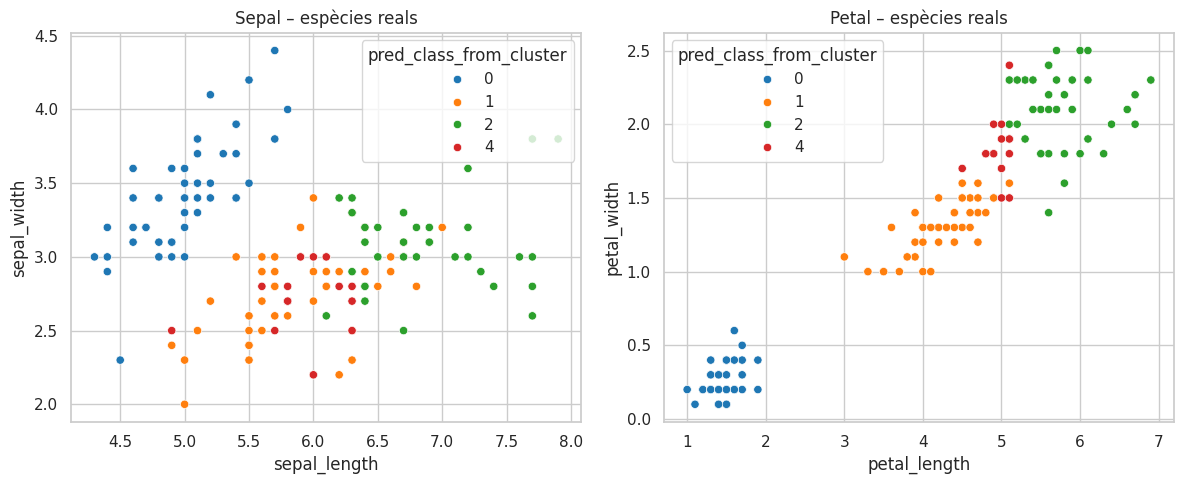

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width",
    hue="pred_class_from_cluster", palette="tab10", ax=axes[0]
)
axes[0].set_title("Sepal – espècies reals")

sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue="pred_class_from_cluster", palette="tab10", ax=axes[1]
)
axes[1].set_title("Petal – espècies reals")

plt.tight_layout()
plt.show()

## 🟦 5. Selecció de K: Elbow i Silhouette

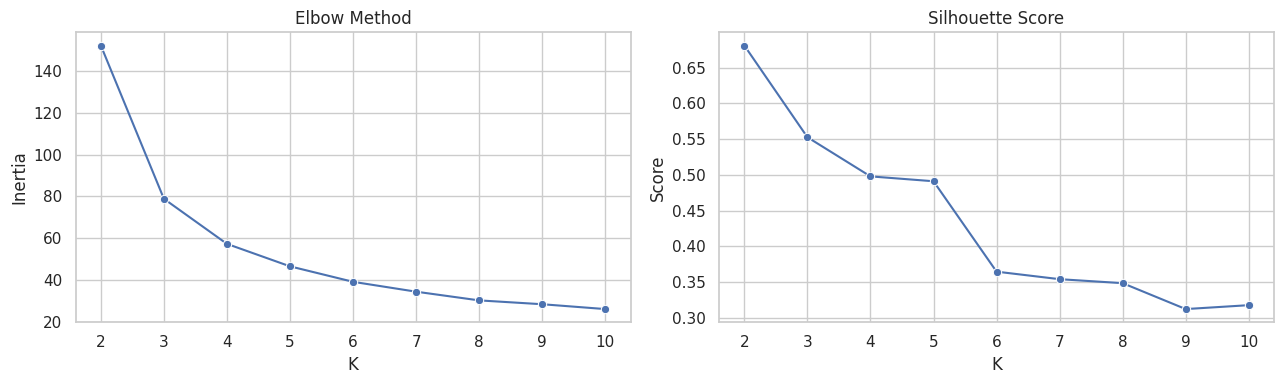

,K,Inertia,Silhouette
0,2,152.347952,0.681046
1,3,78.851441,0.552819
2,4,57.228473,0.498051
3,5,46.461173,0.491240
4,6,39.039987,0.364834
5,7,34.305815,0.354298
6,8,30.132441,0.348735
7,9,28.290635,0.312504
8,10,25.970930,0.317966


In [31]:
from sklearn.metrics import silhouette_score

Ks = range(2, 11)
inertias = []
silhouettes = []

for k in Ks:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        algorithm="lloyd",
        random_state=42
    )
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(x=list(Ks), y=inertias, marker="o", ax=ax[0])
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")

sns.lineplot(x=list(Ks), y=silhouettes, marker="o", ax=ax[1])
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

pd.DataFrame({
    "K": list(Ks),
    "Inertia": inertias,
    "Silhouette": silhouettes
})
